In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [42]:
df = pd.read_csv('Social_Network_Ads.csv').drop(columns=['User ID','Gender'])

In [66]:
df.shape

(405, 3)

In [43]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [60]:
df.loc[len(df)] = [3,70000,1]
df.loc[len(df)] = [89,45000,1]
df.loc[len(df)] = [5,10000,1]
df.loc[len(df)] = [90,50000,0]

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_4792\398241927.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

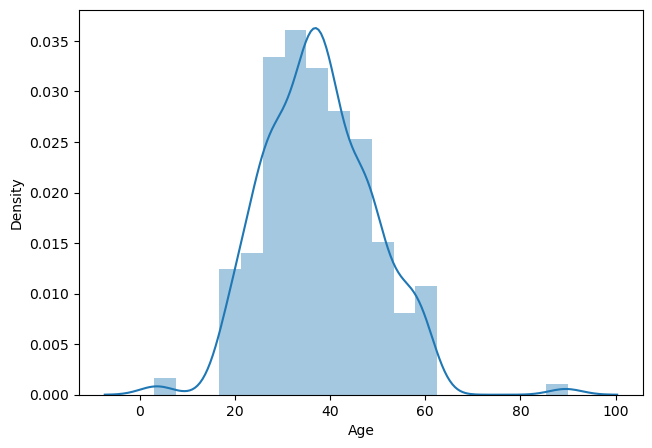

In [61]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Age'])

In [62]:
# Set Limit
Highest = (df['Age'].mean() + 3 * df['Age'].std())
Lowest = (df['Age'].mean() - 3 * df['Age'].std())

In [63]:
Highest

71.92015403582761

In [64]:
# Find Outliers
df[(df['Age'] > Highest) | (df['Age'] < Lowest)]

,Age,EstimatedSalary,Purchased
400,3,70000,1
401,3,70000,1
402,89,45000,1
404,90,50000,0


In [65]:
# Trimming
new_df = df[(df['Age'] < Highest) & (df['Age'] > Lowest)]
new_df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [68]:
# Capping 
df['Age'] = np.where(df['Age']<Lowest,Lowest,
                    np.where(df['Age']>Highest,Highest,df['Age']))

In [69]:
df.shape

(405, 3)

In [71]:
df.describe()

,Age,EstimatedSalary,Purchased
count,405.000000,405.000000,405.000000
mean,37.574412,69486.419753,0.362963
std,11.080862,34050.892870,0.481449
min,3.398364,10000.000000,0.000000
25%,29.000000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,87000.000000,1.000000
max,71.920154,150000.000000,1.000000
